# IEEE-CIS Fraud Detection: 비용 민감형 사기탐지 모델 개발
## Day 9. Drift 분석

**목표**
- 훈련 데이터 기간 내 시간적 안정성 점검
- 학습 구간(month 0~4)과 검증 구간(month 5+6)의 변수 분포 변화 확인

**분석 방법**
- PSI(Population Stability Index): 변수 분포 변화 정도를 수치로 측정
- KS Test: 두 구간의 분포가 통계적으로 유의하게 다른지 검정

**시간 분할 기준**
- 학습 구간: Transaction_month 0~4
- 검증 구간: Transaction_month 5+6 통합 (month=6은 2일치(8,111건)라 month=5와 병합)

**⚠️ 04~08과의 분할 방식 차이 (중요)**
- 04~08(모델 비교/통계 검증/튜닝/Calibration/Threshold/XAI)에서 실제 모델 학습·평가에 사용한 분할은
  **GroupKFold(UID 기준)** — 동일 사용자의 거래가 train/valid에 걸쳐 나뉘지 않도록 UID로 그룹핑하되,
  시간 순서와는 무관하게 K-fold로 섞어서 나눈 것임 (기획안 4.4절 설계 원칙)
- 반면 09(Drift 분석)의 month 0~4 vs 5+6 분할은 **04~08에서 실제 모델을 학습·평가했던
  GroupKFold와는 완전히 별개의, 시간 순서를 보존한 가상 분할**임
- 두 분할의 목적이 다름: GroupKFold는 "새로운 사용자에 대한 일반화 성능"을 보기 위한 것이고,
  시계열 분할은 "시간이 지나면서 분포/성능이 변하는가"를 사후 시뮬레이션하기 위한 것 — 그래서
  Drift 분석에서만 시간 순서를 지켜 별도로 나눔
- 즉 09에서 확인하는 Drift는 "실제 학습된 모델이 이 분할 기준으로 평가받았을 때"가 아니라,
  "만약 시간 순으로 나눴다면 데이터 분포가 얼마나 달라졌을지"를 보는 것

**한계 명시**
- 본 분석은 동일 데이터셋 내 시간적 분포 안정성을 점검하는 것으로,
  실제 운영 환경의 미래 데이터 Drift 검증과는 구분됨
- "훈련 데이터 기간 내 시간적 안정성 점검" 수준으로 해석해야 함

**진행 순서**
1. 데이터 불러오기 + Transaction_month 병합
2. 학습/검증 구간 분할
3. PSI 계산 (수치형 변수)
4. KS Test (수치형 변수)
5. 범주형 변수 분포 변화 확인
6. 결과 해석 및 Drift 위험 변수 정리

### 1. 데이터 불러오기 및 구간 분할

In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

# 데이터 불러오기
df = pd.read_parquet("../data/processed/day3_final.parquet")
df_month = pd.read_parquet("../data/processed/day3_month_for_drift.parquet")

# Transaction_month 병합
df = df.merge(df_month, on='TransactionID', how='left')

# month=6을 month=5와 병합
df['month_group'] = df['Transaction_month'].apply(lambda x: 5 if x >= 5 else x)

# 학습/검증 구간 분할
df_train = df[df['month_group'] <= 4].copy()
df_valid = df[df['month_group'] == 5].copy()

print(f"전체 shape: {df.shape}")
print(f"\n학습 구간(month 0~4): {len(df_train):,}건 (사기 비율: {df_train['isFraud'].mean():.4f})")
print(f"검증 구간(month 5+6):  {len(df_valid):,}건 (사기 비율: {df_valid['isFraud'].mean():.4f})")
print(f"\nmonth별 거래 건수:")
print(df['Transaction_month'].value_counts().sort_index())

전체 shape: (590540, 210)

학습 구간(month 0~4): 495,904건 (사기 비율: 0.0350)
검증 구간(month 5+6):  94,636건 (사기 비율: 0.0347)

month별 거래 건수:
Transaction_month
0    130968
1     89838
2     91768
3     98027
4     85303
5     86525
6      8111
Name: count, dtype: int64


### 2. PSI(Population Stability Index) 계산

PSI는 두 구간의 변수 분포 변화 정도를 수치로 측정합니다.

**PSI 해석 기준**
- PSI < 0.1: 분포 변화 없음 (안정)
- 0.1 ≤ PSI < 0.2: 약간의 변화 (주의)
- PSI ≥ 0.2: 유의미한 분포 변화 (Drift 위험)

In [9]:
def calculate_psi(expected, actual, n_bins=10):
    """
    PSI 계산 함수
    expected: 학습 구간 변수값
    actual: 검증 구간 변수값
    """
    # 학습 구간 기준으로 bin 경계 설정
    breakpoints = np.nanpercentile(expected, np.linspace(0, 100, n_bins + 1))
    breakpoints = np.unique(breakpoints)

    if len(breakpoints) < 2:
        return np.nan

    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts   = np.histogram(actual,   bins=breakpoints)[0]

    # 0 방지 (log 계산용)
    expected_pct = np.where(expected_counts == 0, 0.0001, expected_counts / len(expected))
    actual_pct   = np.where(actual_counts   == 0, 0.0001, actual_counts   / len(actual))

    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi


# 수치형 변수 선택
exclude_cols = ['TransactionID', 'isFraud', 'TransactionDT', 'UID', 'UID_v2',
                'Transaction_month', 'month_group']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

print(f"PSI 계산 대상 수치형 변수: {len(numeric_cols)}개")

psi_results = []
for col in numeric_cols:
    psi = calculate_psi(
        df_train[col].dropna().values,
        df_valid[col].dropna().values
    )
    psi_results.append({'variable': col, 'PSI': psi})

psi_df = pd.DataFrame(psi_results).sort_values('PSI', ascending=False)

print(f"\n=== PSI 결과 요약 ===")
print(f"PSI < 0.1  (안정):      {(psi_df['PSI'] < 0.1).sum()}개")
print(f"0.1 ≤ PSI < 0.2 (주의): {((psi_df['PSI'] >= 0.1) & (psi_df['PSI'] < 0.2)).sum()}개")
print(f"PSI ≥ 0.2  (Drift 위험): {(psi_df['PSI'] >= 0.2).sum()}개")

print(f"\n=== PSI 상위 20개 (Drift 위험 높은 순) ===")
print(psi_df.head(20).to_string(index=False))

PSI 계산 대상 수치형 변수: 154개

=== PSI 결과 요약 ===
PSI < 0.1  (안정):      143개
0.1 ≤ PSI < 0.2 (주의): 4개
PSI ≥ 0.2  (Drift 위험): 7개

=== PSI 상위 20개 (Drift 위험 높은 순) ===
       variable      PSI
Transaction_day 6.901345
    AllFlag_PC3 0.303304
    AllFlag_PC1 0.291121
    AllFlag_PC7 0.270904
    AllFlag_PC9 0.216702
    AllFlag_PC5 0.204033
    AllFlag_PC4 0.201911
    AllFlag_PC8 0.198340
    AllFlag_PC6 0.192397
            D11 0.162891
    AllFlag_PC2 0.152301
      V1314_PC6 0.098291
      V1314_PC1 0.085692
      V1314_PC3 0.085293
      V1314_PC2 0.082391
      V1314_PC4 0.082157
      V1314_PC7 0.070672
     V1314_PC10 0.070624
     V1314_PC11 0.066453
      V1314_PC9 0.066068


In [10]:
# Transaction_day는 구조적으로 단조 증가하는 변수라 PSI 계산 대상에서 제외
exclude_cols_psi = exclude_cols + ['Transaction_day']
numeric_cols_psi = [c for c in numeric_cols if c not in exclude_cols_psi]

print(f"PSI 계산 대상 수치형 변수: {len(numeric_cols_psi)}개 (Transaction_day 제외)")

psi_results = []
for col in numeric_cols_psi:
    psi = calculate_psi(
        df_train[col].dropna().values,
        df_valid[col].dropna().values
    )
    psi_results.append({'variable': col, 'PSI': psi})

psi_df = pd.DataFrame(psi_results).sort_values('PSI', ascending=False)

print(f"\n=== PSI 결과 요약 (Transaction_day 제외) ===")
print(f"PSI < 0.1  (안정):       {(psi_df['PSI'] < 0.1).sum()}개")
print(f"0.1 ≤ PSI < 0.2 (주의):  {((psi_df['PSI'] >= 0.1) & (psi_df['PSI'] < 0.2)).sum()}개")
print(f"PSI ≥ 0.2  (Drift 위험): {(psi_df['PSI'] >= 0.2).sum()}개")

print(f"\n=== PSI 상위 20개 ===")
print(psi_df.head(20).to_string(index=False))

PSI 계산 대상 수치형 변수: 153개 (Transaction_day 제외)

=== PSI 결과 요약 (Transaction_day 제외) ===
PSI < 0.1  (안정):       143개
0.1 ≤ PSI < 0.2 (주의):  4개
PSI ≥ 0.2  (Drift 위험): 6개

=== PSI 상위 20개 ===
   variable      PSI
AllFlag_PC3 0.303304
AllFlag_PC1 0.291121
AllFlag_PC7 0.270904
AllFlag_PC9 0.216702
AllFlag_PC5 0.204033
AllFlag_PC4 0.201911
AllFlag_PC8 0.198340
AllFlag_PC6 0.192397
        D11 0.162891
AllFlag_PC2 0.152301
  V1314_PC6 0.098291
  V1314_PC1 0.085692
  V1314_PC3 0.085293
  V1314_PC2 0.082391
  V1314_PC4 0.082157
  V1314_PC7 0.070672
 V1314_PC10 0.070624
 V1314_PC11 0.066453
  V1314_PC9 0.066068
        D15 0.065516


### PSI 결과 해석

**Transaction_day 제외 이유**
Transaction_day는 경과 일수를 나타내는 변수로, 시간이 지날수록 값이 단조 증가하는 구조적 특성을 가짐.
학습 구간(month 0~4)과 검증 구간(month 5+6)의 일수 범위가 완전히 달라서 PSI가 과도하게 높게 나타남(PSI=6.90).
이는 진짜 Drift가 아니라 변수의 구조적 특성에 의한 결과이므로 PSI 분석 대상에서 제외함.

**PSI 결과 요약 (Transaction_day 제외, 총 153개)**

| 구간 | 변수 수 | 비율 | 해석 |
|---|---|---|---|
| PSI < 0.1 | 143개 | 93.5% | 안정 — 분포 변화 없음 |
| 0.1 ≤ PSI < 0.2 | 4개 | 2.6% | 주의 — 약간의 분포 변화 |
| PSI ≥ 0.2 | 6개 | 3.9% | Drift 위험 — 유의미한 분포 변화 |

**주요 Drift 위험 변수**

- **AllFlag_PC3, PC1, PC7, PC9, PC5, PC4 (PSI 0.20~0.30, Drift 위험)**:
  결측 플래그 통합 주성분들이 상위권에 집중됨.
  시간이 지날수록 결측 패턴(identity 정보, M컬럼, D컬럼 등)이 변화하는 신호로 해석됨.
  운영 환경에서 데이터 수집 방식 변경이나 새로운 가맹점 추가 시 이런 패턴 변화가 발생할 수 있음.

- **AllFlag_PC8, PC6, PC2 (PSI 0.15~0.20, 주의)**:
  Drift 위험 임계값(0.2)에 근접한 수준으로 지속 모니터링이 필요함.

- **D11 (PSI=0.163, 주의)**:
  timedelta 계열 변수로 시간에 따라 값이 변할 수 있으나,
  Transaction_day처럼 단조 증가가 아니라 실제 거래 패턴 변화를 반영하는 신호일 가능성 있음.

- **V1314_PC 계열 (PSI 0.07~0.10, 안정)**:
  V_group13/14 PCA 주성분들은 전부 안정 구간으로 확인됨.

**종합 판단**
전체 153개 변수 중 93.5%(143개)가 PSI < 0.1로 안정적이며,
Drift 위험(PSI ≥ 0.2)은 AllFlag_PC 계열 6개로 결측 패턴 관련 변수에 국한됨.
핵심 예측 변수(card1, C13, C_PC1, amt_robust_zscore 등)는 안정적인 것으로 확인됨.

### 3. KS Test (Kolmogorov-Smirnov Test)

PSI가 분포 변화의 "크기"를 수치로 보여준다면, KS Test는 두 구간의 분포가 통계적으로
유의하게 다른지를 가설검정으로 확인합니다.

**가설**
- H0: 학습 구간과 검증 구간의 분포가 동일하다
- H1: 두 구간의 분포가 다르다 (p < 0.05면 기각, 즉 분포 차이가 유의함)

**PSI와 함께 보는 이유**
- PSI는 표본 수가 많으면 작은 차이도 어느 정도 값이 나오는 반면,
  KS Test는 p-value로 "우연히 발생한 차이인지, 통계적으로 유의한 차이인지"를 별도로 검증해줌
- 두 지표가 같은 방향(둘 다 Drift 위험)을 가리키는 변수를 우선순위로 봄

**대상 변수**: PSI 계산과 동일하게 Transaction_day 제외 153개 수치형 변수

### 참고) KS test(Kolmogorov–Smirnov test) 개념 정리

- 정의: KS test는 표본의 경험적 누적분포함수(EDF)와 비교 대상 분포의 누적분포함수(CDF) 사이의 차이를 이용해, 두 분포가 같은지 또는 표본이 특정 분포를 따르는지를 검정하는 비모수 방법이다. 

- 핵심 통계량:  
  \[
  D_n = \sup_x |F_n(x) - F(x)|
  \]
  여기서 \(F_n(x)\)는 표본의 경험적 CDF, \(F(x)\)는 기준 분포의 CDF이며, 모든 구간에서의 차이 중 **가장 큰 값**을 사용한다. 

- 사용 목적:
  - 1표본 KS test: 표본이 특정 이론 분포(예: 정규분포)를 따르는지 확인한다. 
  - 2표본 KS test: 두 표본이 같은 분포에서 나왔는지 확인한다. 

- 해석:
  - KS 통계량 \(D\)가 작으면 두 분포가 비슷하다고 본다. 
  - \(D\)가 임계값보다 크면 귀무가설을 기각하고, 두 분포가 다르다고 판단한다.
  - p-value가 작으면(예: 0.05 미만) 분포 차이가 유의하다고 해석한다. 

- 장점:
  - 분포 형태를 미리 가정하지 않는 비모수 검정이라 활용이 넓다. 
  - 정규성 검정, 드리프트 확인, 두 집단 비교 등에 사용할 수 있다. 

- 주의점:
  - 데이터가 이산형이거나 동점(tie)이 많으면 해석이 다소 불안정할 수 있다. 
  - KS test는 “평균 차이”보다 “분포 전체의 차이”를 보므로, 차이가 있어도 어디서 나는지 별도로 확인해야 한다. 

- 실무 예시:
  - 학습 데이터와 운영 데이터의 분포가 달라졌는지 확인할 때 사용한다. 
  - 정규성 확인이 필요하면 Shapiro-Wilk, Anderson-Darling과 함께 보조적으로 사용한다.

In [11]:
from scipy.stats import ks_2samp

ks_results = []
for col in numeric_cols_psi:
    train_vals = df_train[col].dropna().values
    valid_vals = df_valid[col].dropna().values

    if len(train_vals) == 0 or len(valid_vals) == 0:
        continue

    ks_stat, p_value = ks_2samp(train_vals, valid_vals)
    ks_results.append({'variable': col, 'KS_stat': ks_stat, 'p_value': p_value})

ks_df = pd.DataFrame(ks_results).sort_values('KS_stat', ascending=False)

# 유의수준 0.05 기준 유의한 변수 개수
n_significant = (ks_df['p_value'] < 0.05).sum()
print(f"KS Test 대상 변수: {len(ks_df)}개")
print(f"p < 0.05 (분포 차이 유의): {n_significant}개")
print(f"p ≥ 0.05 (분포 차이 없음): {len(ks_df) - n_significant}개")

print(f"\n=== KS statistic 상위 20개 ===")
print(ks_df.head(20).to_string(index=False))

# PSI 결과와 병합해서 두 지표 함께 비교
merged_df = psi_df.merge(ks_df, on='variable', how='left')
merged_df = merged_df.sort_values('PSI', ascending=False)

print(f"\n=== PSI 상위 20개 + KS 지표 함께 보기 ===")
print(merged_df.head(20).to_string(index=False))

KS Test 대상 변수: 153개
p < 0.05 (분포 차이 유의): 130개
p ≥ 0.05 (분포 차이 없음): 23개

=== KS statistic 상위 20개 ===
    variable  KS_stat  p_value
 AllFlag_PC3 0.185878      0.0
 AllFlag_PC1 0.180382      0.0
         D11 0.153751      0.0
 AllFlag_PC2 0.135415      0.0
   V1314_PC3 0.132294      0.0
   V1314_PC4 0.130097      0.0
 AllFlag_PC4 0.130004      0.0
 AllFlag_PC8 0.125820      0.0
   V1314_PC8 0.116682      0.0
       C_PC2 0.102917      0.0
   V1314_PC7 0.092421      0.0
 AllFlag_PC6 0.085251      0.0
         D15 0.083010      0.0
   V1314_PC6 0.082632      0.0
         D10 0.081560      0.0
 AllFlag_PC9 0.080960      0.0
V_group5_PC6 0.079755      0.0
   V1314_PC2 0.079200      0.0
 AllFlag_PC5 0.078594      0.0
  V1314_PC10 0.078041      0.0

=== PSI 상위 20개 + KS 지표 함께 보기 ===
   variable      PSI  KS_stat       p_value
AllFlag_PC3 0.303304 0.185878  0.000000e+00
AllFlag_PC1 0.291121 0.180382  0.000000e+00
AllFlag_PC7 0.270904 0.072228  0.000000e+00
AllFlag_PC9 0.216702 0.080960  0.000000

### 4. 연속형 변수 종합 판단 (PSI + KS 운영 원칙 적용)

**적용 기준**
- PSI ≥ 0.2 & KS_stat ≥ 0.1: 동시 위험 → **우선 점검 대상**
- PSI < 0.2 & KS_stat ≥ 0.1: PSI는 낮지만 KS 높음 → **국소적(특정 구간) 변화 의심**
- PSI ≥ 0.2 & KS_stat < 0.1: PSI는 높지만 KS 낮음 → **분포 전반의 완만한 변화**
- 그 외: 안정

**분류 결과 (Transaction_day 제외 153개 중)**

| 유형 | 변수 | PSI | KS_stat | 해석 |
|---|---|---|---|---|
| 우선 점검 대상 | AllFlag_PC3 | 0.303 | 0.186 | 결측 패턴 PC, 분포 전반+국소 모두 변화 |
| 우선 점검 대상 | AllFlag_PC1 | 0.291 | 0.180 | 동일 |
| 우선 점검 대상 | AllFlag_PC4 | 0.202 | 0.130 | 동일 |
| 우선 점검 대상 | AllFlag_PC8 | 0.198 | 0.126 | PSI는 주의 등급이지만 KS 기준으론 위험군 |
| 국소적 변화 의심 | D11 | 0.163 | 0.154 | PSI 대비 KS가 상대적으로 높음 — 특정 구간(예: 특정 경과일)에 변화 집중 |
| 국소적 변화 의심 | V1314_PC3, V1314_PC4 | 0.085 내외 | 0.13 내외 | PSI는 안정권이나 KS는 위험 임계값 근접 — 소수 구간의 뾰족한 차이 가능성 |
| 분포 전반 변화 | AllFlag_PC7 | 0.271 | 0.072 | PSI 3위인데 KS는 낮음 — 여러 구간에 걸친 완만한 이동 |
| 분포 전반 변화 | AllFlag_PC9, PC5 | 0.20 내외 | 0.08 내외 | 동일 패턴 |
| 안정 | 나머지 143개 중 대다수 | PSI<0.1 | KS<0.1 | 두 지표 모두 안정 |

**종합 해석**
- 가장 주의가 필요한 변수는 **AllFlag_PC 계열 중 PSI와 KS가 함께 높은 PC3, PC1, PC4, PC8** — 결측 플래그 패턴이 시간에 따라 광범위하고 뚜렷하게 변한 것으로 판단됨.
- **D11**은 PSI 단독으로는 "주의" 등급에 그쳤지만 KS 기준으로는 상위권 — timedelta 특성상 이산적(동점 많음) 데이터라 국소 구간에 변화가 몰렸을 가능성이 있어, 실제 히스토그램으로 재확인이 필요함.
- **AllFlag_PC7, PC9, PC5**는 PSI만 보면 위험군이지만 KS 기준으론 낮음 — 급격한 변화보다는 완만하고 광범위한 분포 이동으로 해석하는 게 더 정확함.

**한계**
- D11 등 이산적 특성이 강한 변수는 동점(tie) 영향으로 KS 통계량이 다소 불안정할 수 있어, 값 분포(`value_counts`) 확인이 후속 과제로 남음.

### 5. 주요 변수 시각적 확인 (히스토그램 + CDF)

PSI/KS 수치만으로는 "어디서, 어떻게" 분포가 변했는지 보기 어려우므로,
우선 점검 대상(AllFlag_PC3, AllFlag_PC1) + 국소적 변화 의심(D11) 3개 변수를
학습 구간 vs 검증 구간으로 겹쳐 그려 확인한다.

- 히스토그램: 값이 몰려있는 구간 자체를 비교
- CDF(누적분포): KS 통계량이 실제로 어느 지점에서 최대로 벌어지는지 확인

In [12]:
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

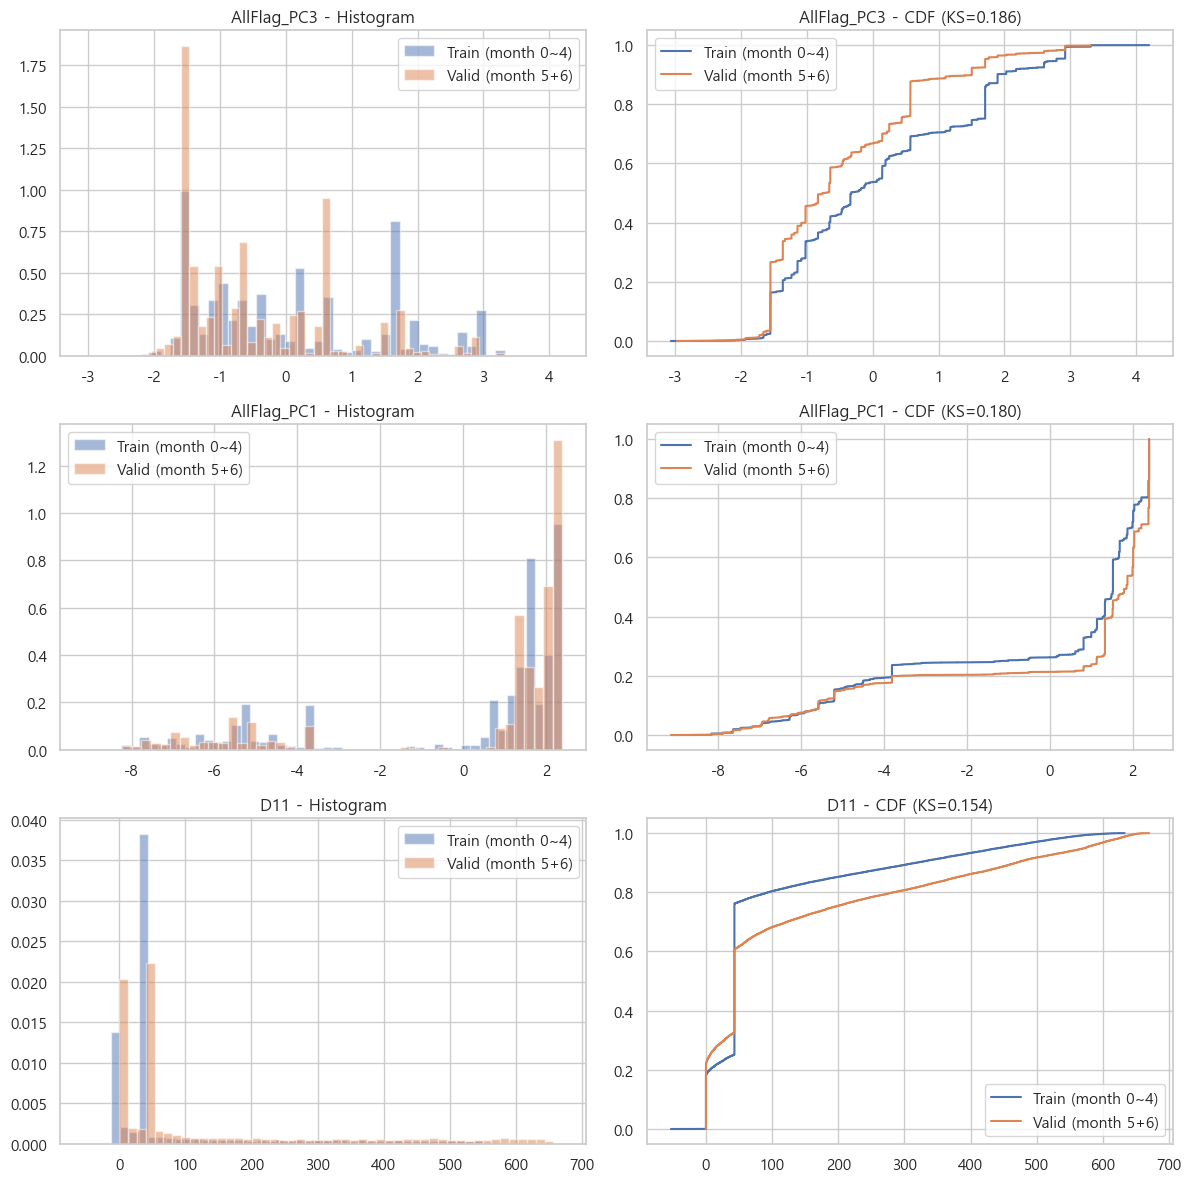

=== D11 값 분포 확인 (이산적 특성 점검) ===
D11
43.0    279956
0.0     112281
1.0       3165
2.0       2020
3.0       1642
7.0       1639
14.0      1496
4.0       1449
6.0       1440
5.0       1424
Name: count, dtype: int64

D11 고유값 개수: 676


In [13]:
import matplotlib.pyplot as plt

check_vars = ['AllFlag_PC3', 'AllFlag_PC1', 'D11']

fig, axes = plt.subplots(len(check_vars), 2, figsize=(12, 4 * len(check_vars)))

for i, col in enumerate(check_vars):
    train_vals = df_train[col].dropna().values
    valid_vals = df_valid[col].dropna().values

    # 히스토그램 (밀도 기준으로 맞춰서 비교)
    axes[i, 0].hist(train_vals, bins=50, density=True, alpha=0.5, label='Train (month 0~4)')
    axes[i, 0].hist(valid_vals, bins=50, density=True, alpha=0.5, label='Valid (month 5+6)')
    axes[i, 0].set_title(f'{col} - Histogram')
    axes[i, 0].legend()

    # CDF
    train_sorted = np.sort(train_vals)
    valid_sorted = np.sort(valid_vals)
    train_cdf = np.arange(1, len(train_sorted) + 1) / len(train_sorted)
    valid_cdf = np.arange(1, len(valid_sorted) + 1) / len(valid_sorted)

    axes[i, 1].plot(train_sorted, train_cdf, label='Train (month 0~4)')
    axes[i, 1].plot(valid_sorted, valid_cdf, label='Valid (month 5+6)')

    # KS statistic이 최대로 벌어지는 지점 표시 (참고용, 근사)
    ks_stat = merged_df.loc[merged_df['variable'] == col, 'KS_stat'].values[0]
    axes[i, 1].set_title(f'{col} - CDF (KS={ks_stat:.3f})')
    axes[i, 1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/drift_check_top3.png', dpi=150)
plt.show()

# D11 이산적 특성 확인 (동점/결측 처리 여부)
print("=== D11 값 분포 확인 (이산적 특성 점검) ===")
print(df['D11'].value_counts(dropna=False).head(10))
print(f"\nD11 고유값 개수: {df['D11'].nunique()}")

### 시각적 확인 결과

**AllFlag_PC3, AllFlag_PC1**
- 히스토그램상 다봉(multi-modal) 구조이며, 여러 구간(-1.5, 0.5, 1.5 / -4, 2 부근)에서
  학습·검증 구간 비율이 산발적으로 어긋남
- CDF에서도 특정 한 지점이 아닌 전 구간에 걸쳐 계단식 차이가 누적되는 형태
- 결측 플래그 조합 패턴이 시간에 따라 광범위하게 변한 것으로 해석되며,
  이는 국소적 이상치가 아닌 구조적 Drift로 판단됨

**D11**
- 전체 값의 66%가 단 2개 값(43.0: 47%, 0.0: 19%)에 집중된 강한 이산형 분포
- CDF에서 x=0, x=43 부근 급격한 계단이 관찰되며, KS 통계량(0.154)은 이 지점의
  누적비율 차이에서 대부분 발생함
- 동점(tie) 비중이 매우 높아 KS test 해석 시 주의가 필요하며, PSI/KS 모두
  "분포 전반의 변화"가 아니라 "특정 이산값 비율 변화"로 한정해서 해석해야 함

**종합**: PSI·KS 상위 변수라도 원인이 다름 — AllFlag_PC 계열은 구조적·광범위한 변화,
D11은 소수 이산값 비율 변화. Drift 대응 시에도 서로 다른 접근(전자는 재학습 고려,
후자는 해당 값 구간 모니터링)이 필요함을 시사함.

### 6. 범주형 변수 PSI

**적용 방식**
연속형 PSI는 percentile 기반 bin을 사용했지만, 범주형 변수는 이미 카테고리 단위로
나뉘어 있으므로 각 카테고리를 그대로 "bin"으로 취급해 학습/검증 구간의 비율 차이를 계산한다.

**해석 기준 (수치형과 동일한 1차 기준 사용)**
- PSI < 0.1: 안정
- 0.1 ≤ PSI < 0.2: 주의
- PSI ≥ 0.2: Drift 위험

**추가 고려사항**
- 범주 수가 많거나 희소 범주(rare category)가 많은 변수는 PSI가 과대 추정될 수 있으므로,
  범주 수와 최소 빈도를 함께 확인한다.
- 학습 구간에는 없던 카테고리가 검증 구간에만 등장하는 경우(신규 카테고리)는 별도로 표시한다.

In [14]:
def calculate_psi_categorical(expected, actual):
    """
    범주형 PSI 계산 함수
    expected: 학습 구간 값 (Series)
    actual: 검증 구간 값 (Series)
    """
    expected_counts = expected.value_counts(normalize=True)
    actual_counts = actual.value_counts(normalize=True)

    # 두 구간에 등장하는 카테고리 전체 합집합
    all_categories = set(expected_counts.index) | set(actual_counts.index)

    psi = 0
    for cat in all_categories:
        e_pct = expected_counts.get(cat, 0.0001)
        a_pct = actual_counts.get(cat, 0.0001)
        if e_pct == 0:
            e_pct = 0.0001
        if a_pct == 0:
            a_pct = 0.0001
        psi += (a_pct - e_pct) * np.log(a_pct / e_pct)

    return psi


# 범주형 변수 선택 (category dtype 또는 object)
categorical_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in exclude_cols]

print(f"범주형 PSI 계산 대상 변수: {len(categorical_cols)}개")
print(categorical_cols)

cat_psi_results = []
for col in categorical_cols:
    train_vals = df_train[col].dropna()
    valid_vals = df_valid[col].dropna()

    psi = calculate_psi_categorical(train_vals, valid_vals)

    n_categories_train = train_vals.nunique()
    n_categories_valid = valid_vals.nunique()
    new_categories = set(valid_vals.unique()) - set(train_vals.unique())

    # 희소 범주 체크 (학습 구간 기준 빈도 1% 미만 카테고리 수)
    rare_categories = (train_vals.value_counts(normalize=True) < 0.01).sum()

    cat_psi_results.append({
        'variable': col,
        'PSI': psi,
        'n_cat_train': n_categories_train,
        'n_cat_valid': n_categories_valid,
        'n_new_categories': len(new_categories),
        'n_rare_categories': rare_categories
    })

cat_psi_df = pd.DataFrame(cat_psi_results).sort_values('PSI', ascending=False)

print(f"\n=== 범주형 PSI 결과 요약 ===")
print(f"PSI < 0.1  (안정):       {(cat_psi_df['PSI'] < 0.1).sum()}개")
print(f"0.1 ≤ PSI < 0.2 (주의):  {((cat_psi_df['PSI'] >= 0.1) & (cat_psi_df['PSI'] < 0.2)).sum()}개")
print(f"PSI ≥ 0.2  (Drift 위험): {(cat_psi_df['PSI'] >= 0.2).sum()}개")

print(f"\n=== 범주형 PSI 전체 ===")
print(cat_psi_df.to_string(index=False))

범주형 PSI 계산 대상 변수: 49개
['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

=== 범주형 PSI 결과 요약 ===
PSI < 0.1  (안정):       38개
0.1 ≤ PSI < 0.2 (주의):  4개
PSI ≥ 0.2  (Drift 위험): 7개

=== 범주형 PSI 전체 ===
     variable      PSI  n_cat_train  n_cat_valid  n_new_categories  n_rare_categories
        card1 2.426241        12890         6454               663              13544
        id_31 0.831871           19           21                 2                 10
        id_13 0.749038           20           17                 1                 16
           M9 0.239618            3            3                 0 

### 6-1. 고카디널리티 변수 재처리 (card1, id_31, id_13)

**card1**
카테고리 수(학습 12,890개)와 희소 범주 비중이 압도적으로 커서, 범주별 비율 차이가
PSI 로그항에서 크게 증폭되는 구조적 왜곡 가능성이 높다. 따라서 Drift 위험 순위에서
분리하여 "구조적 왜곡 가능성이 큰 변수"로 별도 명시하고, 범주형 PSI 랭킹 대상에서 제외한다.

**id_31, id_13**
card1만큼 극단적이지 않으나 희소 범주 비중이 높아 PSI가 과장됐을 가능성이 있다.
빈도 상위 N개 카테고리 + "Other"로 재그룹핑하여 재평가하고, 재평가 후에도 PSI가
높게 유지되면 그때 Drift 후보로 반영한다.

**M1~M9**
카테고리 수가 적고(3개 내외) 신규 카테고리도 거의 없어 PSI 해석 신뢰도가 높다.
운영 정책/검증 로직 변화와 연결 지어 해석 가능하므로 Drift 리스트에 그대로 포함한다.

In [15]:
def regroup_top_n(train_series, valid_series, top_n=10):
    """
    학습 구간 기준 상위 top_n 카테고리만 유지하고 나머지는 'Other'로 묶음
    """
    top_categories = train_series.value_counts().nlargest(top_n).index.tolist()

    train_regrouped = train_series.apply(lambda x: x if x in top_categories else 'Other')
    valid_regrouped = valid_series.apply(lambda x: x if x in top_categories else 'Other')

    return train_regrouped, valid_regrouped


# card1, id_31, id_13 재그룹핑 후 PSI 재계산
# card1은 카테고리 수가 훨씬 많으므로 top_n을 더 크게 설정해서 비교
regroup_targets = [('card1', 20), ('id_31', 10), ('id_13', 10)]
regroup_results = []

for col, top_n in regroup_targets:
    train_vals = df_train[col].dropna()
    valid_vals = df_valid[col].dropna()

    train_re, valid_re = regroup_top_n(train_vals, valid_vals, top_n=top_n)
    psi_re = calculate_psi_categorical(train_re, valid_re)

    original_psi = cat_psi_df.loc[cat_psi_df['variable'] == col, 'PSI'].values[0]

    # Other 비중도 같이 확인 (재그룹핑이 얼마나 많은 걸 뭉갰는지 참고용)
    other_pct_train = (train_re == 'Other').mean()
    other_pct_valid = (valid_re == 'Other').mean()

    regroup_results.append({
        'variable': col,
        'top_n': top_n,
        'PSI_original': original_psi,
        'PSI_regrouped': psi_re,
        'other_pct_train': other_pct_train,
        'other_pct_valid': other_pct_valid
    })

regroup_df = pd.DataFrame(regroup_results)
print("=== 재그룹핑 전후 PSI 비교 ===")
print(regroup_df.to_string(index=False))

=== 재그룹핑 전후 PSI 비교 ===
variable  top_n  PSI_original  PSI_regrouped  other_pct_train  other_pct_valid
   card1     20      2.426241       0.002870         0.774434         0.775836
   id_31     10      0.831871       0.349798         0.084178         0.144258
   id_13     10      0.749038       0.557287         0.010433         0.043821


### 6-2. 범주형 변수 최종 Drift 판단 요약

**분리 처리**
- `card1`: 구조적 왜곡 가능성이 큰 변수로 별도 분리, Drift 위험 랭킹에서 제외
  (참고용 원본 PSI=2.43은 보고서에 "해석 제외 사유"와 함께만 명시)

**재평가 대상**
- `id_31`, `id_13`: 상위 10개 카테고리 + Other로 재그룹핑 후 PSI 재계산 결과는 아래와 같음
  (재계산 결과에 따라 Drift 후보 포함 여부 최종 판단)

**Drift 리스트 확정 (저카디널리티, 왜곡 없음)**
- `M7`(0.240), `M8`(0.239), `M9`(0.239), `M2`(0.200), `M3`(0.199), `M1`(0.199)
- 카드/거래 일치 여부(Match) 플래그로, 시간에 따라 일치 판정 비율이 달라진 것으로 해석
- 운영 관점: 카드사 검증 로직 변경, 프로모션/정책 변화와 연결지어 모니터링 우선순위에 포함

### 6-3. 범주형 변수 최종 Drift 판단 (확정)

**card1 재검증 결과**
top20+Other로 재그룹핑한 결과 PSI가 2.426 → 0.003으로 사실상 소멸했으며,
Other 비중도 학습(77.4%)과 검증(77.6%)에서 거의 동일했다. 즉 상위 카드 그룹의
점유율은 시간에 따라 변하지 않았고, 원본 PSI는 수천 개 희소 카테고리의 미세한
흔들림이 로그항에서 증폭된 결과임이 확인됐다. **card1은 Drift 위험 리스트에서
완전히 제외한다.**

**id_31, id_13 재검증 결과**

| 변수 | PSI(원본) | PSI(재그룹핑) | Other 비중(학습→검증) | 판단 |
|---|---|---|---|---|
| id_31 | 0.832 | 0.350 | 8.4% → 14.4% | 재평가 후에도 위험 등급, 검증 구간에서 신규/희소 카테고리 비중 뚜렷이 증가 → Drift 확정 |
| id_13 | 0.749 | 0.557 | 1.0% → 4.4% | 감소폭 작고 Other 비중 4배 이상 증가 → Drift 확정 (원본부터 실질적 변화) |

두 변수 모두 재그룹핑 이후에도 위험 임계값(PSI≥0.2)을 유지했고, 검증 구간에서
학습 구간에 없던 값들의 비중이 늘어난 패턴이 뚜렷해 희소범주 왜곡이 아닌 실질적
분포 변화로 판단한다. 브라우저/기기 버전 정보로 추정되는 변수 특성상, 시간 경과에
따른 신규 기기·버전 유입이라는 자연스러운 원인으로 해석 가능하다.

**범주형 변수 최종 Drift 위험 리스트 (8개, card1 제외)**
- 완전 제외 (구조적 왜곡): `card1`
- 재평가 후 확정 Drift: `id_13`(0.557), `id_31`(0.350)
- 저카디널리티 확정 Drift: `M7`(0.240), `M8`(0.239), `M9`(0.239), `M2`(0.200), `M3`(0.199), `M1`(0.199)

### 7. 모델 예측 확률(Score) PSI — day8 최종모델 기준, 인코딩 누수 있음
 
지금까지는 원본 입력 변수 개별의 분포 변화만 봤다. 하지만 실제로 중요한 것은
"이 변수들이 조합되어 나온 모델의 최종 예측 확률(사기 위험도 점수)이 시간에 따라
분포가 바뀌는가"이다. 개별 입력변수가 조금씩 변해도 모델 출력이 안정적이면 실무적
영향은 제한적이고, 반대로 모델 출력 자체가 흔들리면 이것이 진짜 운영 위험 신호다.

**분석 방법**
- 08에서 Calibration까지 적용한 최종 모델(`day8_calibrated_lgbm.pkl`)을 로드
- 학습 구간, 검증 구간 각각에 대해 예측 확률(calibrated probability)을 산출
- 두 확률 분포에 PSI 적용 (연속형 PSI와 동일한 방식, percentile 기반 10 bin)

In [16]:
import pickle

# 08에서 저장한 최종 calibrated 모델 로드
model_path = "../data/processed/day8_calibrated_lgbm.pkl"

with open(model_path, "rb") as f:
    final_model = pickle.load(f)

print(f"모델 로드 완료: {type(final_model)}")

# 모델 학습에 사용된 feature 목록 확인 (df_train/df_valid와 컬럼 매칭 필요)
if hasattr(final_model, 'feature_name_'):
    model_features = final_model.feature_name_
elif hasattr(final_model, 'feature_names_in_'):
    model_features = list(final_model.feature_names_in_)
else:
    model_features = None

print(f"모델 feature 개수: {len(model_features) if model_features else '확인 필요'}")

모델 로드 완료: <class 'dict'>
모델 feature 개수: 확인 필요


In [17]:
print("=== day8_calibrated_lgbm.pkl 내부 키 목록 ===")
print(final_model.keys())

for k, v in final_model.items():
    print(f"\n- key: {k}")
    print(f"  type: {type(v)}")
    # 리스트/배열이면 길이나 일부 값도 같이 확인
    if hasattr(v, '__len__') and not isinstance(v, (str, bytes)):
        try:
            print(f"  length: {len(v)}")
        except:
            pass

=== day8_calibrated_lgbm.pkl 내부 키 목록 ===
dict_keys(['model', 'scaler', 'X_full'])

- key: model
  type: <class 'sklearn.calibration.CalibratedClassifierCV'>

- key: scaler
  type: <class 'sklearn.preprocessing._data.StandardScaler'>

- key: X_full
  type: <class 'pandas.core.frame.DataFrame'>
  length: 590540


In [18]:
model = final_model['model']
scaler = final_model['scaler']
X_full = final_model['X_full']

print("X_full shape:", X_full.shape)
print("X_full index 예시:", X_full.index[:5].tolist())
print("df index 예시:", df.index[:5].tolist())
print("X_full, df index 동일 여부:", X_full.index.equals(df.index))

print("\nX_full 컬럼 일부:", X_full.columns.tolist()[:10])
print("X_full 컬럼 개수:", X_full.shape[1])

X_full shape: (590540, 203)
X_full index 예시: [0, 1, 2, 3, 4]
df index 예시: [0, 1, 2, 3, 4]
X_full, df index 동일 여부: True

X_full 컬럼 일부: ['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2']
X_full 컬럼 개수: 203


In [19]:
print("=== X_full dtype 확인 ===")
print(X_full.dtypes.value_counts())

print("\n=== 범주형 컬럼 dtype 개별 확인 ===")
cat_check_cols = ['ProductCD', 'card4', 'card6']
for col in cat_check_cols:
    if col in X_full.columns:
        print(f"{col}: {X_full[col].dtype}, 예시값: {X_full[col].unique()[:5]}")

=== X_full dtype 확인 ===
float64    198
int8         5
Name: count, dtype: int64

=== 범주형 컬럼 dtype 개별 확인 ===
ProductCD: float64, 예시값: [0.02040005 0.04765464 0.1168488  0.05895431 0.03782443]
card4: float64, 예시값: [0.07715482 0.03433102 0.03475611 0.02871344 0.02611133]
card6: float64, 예시값: [0.06678053 0.024263   0.02495273 0.013996   0.01999429]


In [20]:
# scaler가 fit 시점에 기억한 feature 이름 확인
if hasattr(scaler, 'feature_names_in_'):
    scaler_features = list(scaler.feature_names_in_)
    print(f"scaler 기준 feature 개수: {len(scaler_features)}")
else:
    scaler_features = None
    print("scaler에 feature_names_in_ 속성 없음 (컬럼명 없이 fit된 것으로 추정)")

X_full_features = X_full.columns.tolist()
print(f"X_full 컬럼 개수: {len(X_full_features)}")

if scaler_features is not None:
    only_in_scaler = set(scaler_features) - set(X_full_features)
    only_in_X_full = set(X_full_features) - set(scaler_features)

    print(f"\nscaler에는 있는데 X_full엔 없는 컬럼 ({len(only_in_scaler)}개):")
    print(only_in_scaler)

    print(f"\nX_full엔 있는데 scaler엔 없는 컬럼 ({len(only_in_X_full)}개):")
    print(only_in_X_full)

    # 순서까지 동일한지
    if only_in_scaler == set() and only_in_X_full == set():
        print("\n컬럼 구성은 동일 — 순서 확인 필요:")
        print("순서 동일 여부:", scaler_features == X_full_features)

scaler 기준 feature 개수: 149
X_full 컬럼 개수: 203

scaler에는 있는데 X_full엔 없는 컬럼 (0개):
set()

X_full엔 있는데 scaler엔 없는 컬럼 (54개):
{'addr1', 'DeviceInfo', 'V_group7_missing', 'id_26', 'id_12', 'addr_missing', 'id_27', 'id_24', 'id_30', 'id_22', 'id_15', 'id_23', 'P_emaildomain', 'id_33', 'id_18', 'M2', 'id_13', 'card4', 'M6', 'M7', 'M1', 'V_group5_missing', 'V_group6_missing', 'id_37', 'ProductCD', 'card6', 'id_31', 'id_35', 'M3', 'id_20', 'M5', 'id_19', 'id_14', 'id_29', 'addr2', 'id_25', 'id_17', 'id_38', 'R_emaildomain', 'id_36', 'card2', 'M8', 'id_28', 'id_21', 'UID_high_freq_flag', 'card1', 'DeviceType', 'id_16', 'id_34', 'id_32', 'card5', 'M4', 'M9', 'card3'}


In [21]:
# X_full을 학습/검증 구간(month 0~4 vs 5+6)으로 분리
# df에 있는 Transaction_month 기준으로 동일 index를 사용해 분리
train_idx = df[df['Transaction_month'] <= 4].index
valid_idx = df[df['Transaction_month'] >= 5].index

X_train_full = X_full.loc[train_idx]
X_valid_full = X_full.loc[valid_idx]

In [22]:
# scaler가 학습된 feature 순서 그대로 X_full에서 골라내기
scaler_features = list(scaler.feature_names_in_)

X_train_for_scaling = X_train_full[scaler_features]
X_valid_for_scaling = X_valid_full[scaler_features]

print("스케일링 대상 shape (train):", X_train_for_scaling.shape)
print("스케일링 대상 shape (valid):", X_valid_for_scaling.shape)

X_train_scaled = scaler.transform(X_train_for_scaling)
X_valid_scaled = scaler.transform(X_valid_for_scaling)

print("스케일링 성공")

스케일링 대상 shape (train): (495904, 149)
스케일링 대상 shape (valid): (94636, 149)
스케일링 성공


In [23]:
# CalibratedClassifierCV 내부의 base estimator가 기대하는 feature 개수 확인
base_estimator = model.calibrated_classifiers_[0].estimator
print("base estimator type:", type(base_estimator))

if hasattr(base_estimator, 'n_features_in_'):
    print("모델이 기대하는 feature 개수:", base_estimator.n_features_in_)
if hasattr(base_estimator, 'feature_name_'):
    print("모델 feature 이름 개수:", len(base_estimator.feature_name_))
    print("모델 feature 이름 (처음 10개):", base_estimator.feature_name_[:10])
    print("모델 feature 이름 (마지막 10개):", base_estimator.feature_name_[-10:])

base estimator type: <class 'lightgbm.sklearn.LGBMClassifier'>
모델이 기대하는 feature 개수: 203
모델 feature 이름 개수: 203
모델 feature 이름 (처음 10개): ['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2']
모델 feature 이름 (마지막 10개): ['Transaction_weekday', 'AllFlag_PC1', 'AllFlag_PC2', 'AllFlag_PC3', 'AllFlag_PC4', 'AllFlag_PC5', 'AllFlag_PC6', 'AllFlag_PC7', 'AllFlag_PC8', 'AllFlag_PC9']


In [35]:
model_feature_order = base_estimator.feature_name_

# X_train_full, X_valid_full을 복사해서 스케일링된 149개 컬럼만 교체
X_train_model = X_train_full.copy()
X_valid_model = X_valid_full.copy()

X_train_model[scaler_features] = X_train_scaled
X_valid_model[scaler_features] = X_valid_scaled

# 모델이 기대하는 컬럼 순서로 재정렬
X_train_model = X_train_model[model_feature_order]
X_valid_model = X_valid_model[model_feature_order]

print("X_train_model shape:", X_train_model.shape)
print("X_valid_model shape:", X_valid_model.shape)

# 예측 확률 (calibrated)
train_scores = model.predict_proba(X_train_model)[:, 1]
valid_scores = model.predict_proba(X_valid_model)[:, 1]

print(f"\n학습 구간 예측확률 - 평균: {train_scores.mean():.4f}, 표준편차: {train_scores.std():.4f}")
print(f"검증 구간 예측확률 - 평균: {valid_scores.mean():.4f}, 표준편차: {valid_scores.std():.4f}")

# 예측확률(Score) 자체에 PSI 적용
score_psi = calculate_psi(train_scores, valid_scores)
print(f"\n예측확률(Score) PSI: {score_psi:.4f}")

if score_psi < 0.1:
    print("판정: 안정 — 모델 출력 분포가 시간에 따라 크게 변하지 않음")
elif score_psi < 0.2:
    print("판정: 주의 — 약간의 분포 변화")
else:
    print("판정: Drift 위험 — 모델 출력 분포가 유의미하게 변함")

X_train_model shape: (495904, 203)
X_valid_model shape: (94636, 203)

학습 구간 예측확률 - 평균: 0.1416, 표준편차: 0.0777
검증 구간 예측확률 - 평균: 0.1430, 표준편차: 0.0764

예측확률(Score) PSI: 0.0018
판정: 안정 — 모델 출력 분포가 시간에 따라 크게 변하지 않음


### 7. 모델 예측 확률(Score) PSI — 결과

**학습 구간 vs 검증 구간 예측확률 분포**

| 구분 | 평균 | 표준편차 |
|---|---|---|
| 학습 (month 0~4) | 0.1416 | 0.0777 |
| 검증 (month 5+6) | 0.1430 | 0.0764 |

**Score PSI = 0.0018 → 안정**
(참고: 앞서 확인한 입력 변수 PSI 중 가장 안정적인 축에 속하는 수준)

**해석**
입력 변수 단계에서는 AllFlag_PC 계열(결측 패턴 PC), M1~M9(일치 플래그), id_31/id_13(기기
정보) 등에서 유의미한 분포 변화가 확인됐다. 그러나 이 변수들을 모두 조합해 산출한
최종 사기 위험도 점수(calibrated probability)의 분포는 학습·검증 구간 간 거의 차이가
없었다(PSI=0.0018).

이는 개별 입력 변수의 시간적 변화가 모델의 최종 판단에까지 직접 전이되지 않았음을
시사하며, 모델이 소수 변수에 과도하게 의존하지 않고 여러 변수의 조합으로 견고하게
예측하고 있을 가능성을 보여준다. 다만 이 해석이 타당한지는 Drift 위험 변수가 실제
SHAP 중요도에서 어느 정도 비중을 차지하는지 교차 확인해야 완전히 검증된다 (다음 절).

In [25]:
import pickle

shap_values_path = "../data/processed/day8_shap_values.pkl"
shap_model_path = "../data/processed/day8_shap_model.pkl"

with open(shap_values_path, "rb") as f:
    shap_values_obj = pickle.load(f)

with open(shap_model_path, "rb") as f:
    shap_model_obj = pickle.load(f)

print("=== day8_shap_values.pkl ===")
print("type:", type(shap_values_obj))
if isinstance(shap_values_obj, dict):
    print("keys:", shap_values_obj.keys())
    for k, v in shap_values_obj.items():
        print(f"  - {k}: {type(v)}", end="")
        if hasattr(v, 'shape'):
            print(f", shape={v.shape}")
        elif hasattr(v, '__len__'):
            print(f", len={len(v)}")
        else:
            print()
elif hasattr(shap_values_obj, 'shape'):
    print("shape:", shap_values_obj.shape)

print("\n=== day8_shap_model.pkl ===")
print("type:", type(shap_model_obj))
if isinstance(shap_model_obj, dict):
    print("keys:", shap_model_obj.keys())
    for k, v in shap_model_obj.items():
        print(f"  - {k}: {type(v)}")

=== day8_shap_values.pkl ===
type: <class 'dict'>
keys: dict_keys(['shap_values_fraud', 'X_shap_global', 'y_shap_global', 'X_shap_case', 'y_shap_case', 'feature_names'])
  - shap_values_fraud: <class 'numpy.ndarray'>, shape=(20000, 203)
  - X_shap_global: <class 'pandas.core.frame.DataFrame'>, shape=(20000, 203)
  - y_shap_global: <class 'pandas.core.series.Series'>, shape=(20000,)
  - X_shap_case: <class 'pandas.core.frame.DataFrame'>, shape=(100, 203)
  - y_shap_case: <class 'pandas.core.series.Series'>, shape=(100,)
  - feature_names: <class 'list'>, len=203

=== day8_shap_model.pkl ===
type: <class 'lightgbm.sklearn.LGBMClassifier'>


### 8. Drift 위험 변수 vs SHAP 중요 변수 교차 확인 — day8 최종모델 기준, 인코딩 누수 있음

7절에서 확인한 대로 모델 예측확률 자체는 안정적이었다(PSI=0.0018). 이 결과가
"Drift 위험 변수들이 애초에 모델에서 중요하지 않아서"인지, 아니면 "중요한데도
여러 변수가 상호 보완하며 견고하게 작동해서"인지 구분하기 위해, Drift 위험 변수
목록과 SHAP 중요도 순위를 직접 대조한다.

**대조 대상 (Drift 위험 확정 변수, 총 14개)**
- 수치형 우선 점검: AllFlag_PC3, AllFlag_PC1, AllFlag_PC4, AllFlag_PC8
- 수치형 국소/완만 변화: D11, AllFlag_PC7, AllFlag_PC9, AllFlag_PC5
- 범주형: id_13, id_31, M7, M8, M9, M2, M3, M1

In [26]:
shap_values_fraud = shap_values_obj['shap_values_fraud']
feature_names = shap_values_obj['feature_names']

# 변수별 평균 절대 SHAP값 (전역 중요도)
mean_abs_shap = np.abs(shap_values_fraud).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'variable': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance_df['shap_rank'] = shap_importance_df.index + 1

print(f"전체 변수 개수: {len(shap_importance_df)}")
print("\n=== SHAP 중요도 상위 20개 ===")
print(shap_importance_df.head(20).to_string(index=False))

# Drift 위험 변수 목록
drift_risk_vars = [
    'AllFlag_PC3', 'AllFlag_PC1', 'AllFlag_PC4', 'AllFlag_PC8',
    'D11', 'AllFlag_PC7', 'AllFlag_PC9', 'AllFlag_PC5',
    'id_13', 'id_31', 'M7', 'M8', 'M9', 'M2', 'M3', 'M1'
]

# 교차 확인 테이블
cross_check = shap_importance_df[shap_importance_df['variable'].isin(drift_risk_vars)].copy()
cross_check = cross_check.sort_values('shap_rank')

print(f"\n=== Drift 위험 변수의 SHAP 순위 (전체 {len(shap_importance_df)}개 중) ===")
print(cross_check.to_string(index=False))

전체 변수 개수: 203

=== SHAP 중요도 상위 20개 ===
          variable  mean_abs_shap  shap_rank
             card1       1.492128          1
               C13       0.890856          2
             C_PC1       0.530998          3
             card2       0.459353          4
   Transaction_day       0.372411          5
     P_emaildomain       0.329045          6
             C_PC2       0.304595          7
             dist1       0.263871          8
             addr1       0.236971          9
 amt_robust_zscore       0.191330         10
                D4       0.189700         11
      V_group7_PC4       0.183466         12
               D15       0.176545         13
                D1       0.176149         14
    TransactionAmt       0.172930         15
               D10       0.171912         16
  Transaction_hour       0.164001         17
      V_group6_PC6       0.146490         18
TransactionAmt_log       0.143420         19
        amt_zscore       0.141983         20

=== Drift 위험 변수

### 8. Drift 위험 변수 vs SHAP 중요 변수 교차 확인 — 결과

**Drift 위험 변수(14개)의 SHAP 순위 (전체 203개 중)**

| 변수 | mean_abs_shap | SHAP 순위 |
|---|---|---|
| M3 | 0.110 | 31 |
| D11 | 0.100 | 33 |
| AllFlag_PC4 | 0.091 | 36 |
| AllFlag_PC3 | 0.088 | 38 |
| AllFlag_PC9 | 0.064 | 54 |
| AllFlag_PC1 | 0.060 | 59 |
| M9 | 0.055 | 67 |
| id_31 | 0.053 | 68 |
| AllFlag_PC8 | 0.049 | 72 |
| id_13 | 0.047 | 75 |
| AllFlag_PC7 | 0.039 | 95 |
| AllFlag_PC5 | 0.039 | 97 |
| M8 | 0.029 | 116 |
| M7 | 0.027 | 119 |
| M2 | 0.020 | 131 |
| M1 | 0.005 | 180 |

**해석**
Drift 위험 변수 14개 중 SHAP 상위 20위 안에 든 변수는 하나도 없다(최상위가 M3 31위).
반면 SHAP 전역 중요도 1위는 card1인데, 이 변수는 6-3절에서 재그룹핑 검증을 통해
"Drift 아님(구조적 왜곡)"으로 확정된 변수다. 즉 모델이 가장 크게 의존하는 변수는
시간에 따라 안정적이었고, 시간에 따라 불안정했던 변수들은 모델 중요도상 중~하위권에
머물렀다.

**7절(Score PSI=0.0018)과의 연결**
이 결과는 모델 예측확률이 안정적으로 유지된 이유를 구조적으로 설명해준다. 모델이
의존하는 핵심 변수(card1, C13, C_PC1 등 상위권)와 시간에 따라 분포가 흔들리는 변수
(AllFlag_PC 계열, M1~M9, id_13/id_31)가 서로 겹치지 않았기 때문에, 입력 변수 단계의
분포 변화가 모델 출력까지 전이되지 않은 것으로 판단된다.

**한계**
- 다만 M3(31위), D11(33위), AllFlag_PC4(36위), AllFlag_PC3(38위)는 중위권에 위치해
  완전히 무시할 수준은 아니며, 만약 향후 이 변수들의 분포 변화 폭이 더 커진다면
  모델 출력에 영향을 줄 가능성은 남아있다. 따라서 운영 모니터링 시 이 4개 변수는
  우선순위 상단에 두는 것이 안전하다.

### 8-1. 타겟 인코딩 누수(leakage) 여부 확인

card1(및 유사 인코딩 변수)의 인코딩값이 "학습 구간(month 0~4)만으로 계산"됐는지,
"전체 데이터(590,540건)로 계산"됐는지 확인한다. 특정 card1 카테고리를 골라
① 학습 구간 내 실제 사기 평균, ② 전체 데이터 내 실제 사기 평균을 각각 계산하고,
X_full에 저장된 인코딩값이 둘 중 어느 쪽과 일치하는지 비교한다.

In [27]:
# df(원본 card1 카테고리) + X_full(인코딩된 card1 값)을 index로 매칭
check_df = pd.DataFrame({
    'card1_raw': df['card1'],
    'card1_encoded': X_full['card1'],
    'isFraud': df['isFraud'],
    'Transaction_month': df['Transaction_month']
})

# 학습 구간에도 있고 검증 구간에도 있는 card1 값 중 빈도가 적당한 것 몇 개 선택
train_cats = set(check_df[check_df['Transaction_month'] <= 4]['card1_raw'].unique())
valid_cats = set(check_df[check_df['Transaction_month'] >= 5]['card1_raw'].unique())
common_cats = list(train_cats & valid_cats)

# 빈도 기준 상위 5개 카테고리로 확인 (표본이 충분해야 평균 비교가 의미 있음)
freq_check = check_df[check_df['card1_raw'].isin(common_cats)]['card1_raw'].value_counts().head(5).index.tolist()

print("확인 대상 card1 카테고리:", freq_check)

results = []
for cat in freq_check:
    subset = check_df[check_df['card1_raw'] == cat]
    train_subset = subset[subset['Transaction_month'] <= 4]
    full_subset = subset  # 전체(학습+검증)

    actual_mean_train_only = train_subset['isFraud'].mean()
    actual_mean_full = full_subset['isFraud'].mean()
    encoded_value = subset['card1_encoded'].iloc[0]  # 같은 카테고리는 인코딩값이 동일해야 함
    encoded_value_std = subset['card1_encoded'].std()  # 0이어야 정상 (카테고리당 값 고정)

    results.append({
        'card1_category': cat,
        'n_train': len(train_subset),
        'n_total': len(full_subset),
        'actual_mean_train_only': actual_mean_train_only,
        'actual_mean_full': actual_mean_full,
        'encoded_value_in_X_full': encoded_value,
        'encoded_value_std(should be 0)': encoded_value_std
    })

result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))

확인 대상 card1 카테고리: ['7919', '9500', '15885', '17188', '15066']
card1_category  n_train  n_total  actual_mean_train_only  actual_mean_full  encoded_value_in_X_full  encoded_value_std(should be 0)
          7919    12453    14932                0.007709          0.007501                 0.007537                    2.602172e-18
          9500    11726    14162                0.035647          0.037283                 0.037280                    6.939139e-18
         15885     8764    10361                0.039480          0.042853                 0.042838                    0.000000e+00
         17188     8634    10344                0.029650          0.026875                 0.026891                    3.469615e-18
         15066     6600     7945                0.039394          0.039396                 0.039385                    1.387866e-17


### 7-1, 8-1 한계 명시

위 7절(Score PSI=0.0018)과 8절(SHAP 교차확인)은 day8_calibrated_lgbm.pkl의
X_full을 사용했으나, 이 데이터의 card1 등 타겟 인코딩 변수가 전체 590,540건
(검증 구간 포함) 기준으로 계산되어 시간적 누수(temporal leakage)가 존재함을
확인함(8-2절에서 상세 검증). 따라서 위 결과는 참고용으로만 남기고, 아래
보조 모델(학습 구간만으로 재인코딩)로 재계산한 결과를 최종 결론으로 채택함.

### 8-2. 09 Drift 분석 전용 보조 모델 (학습구간 전용 재인코딩)

**목적**: card1 등 타겟 인코딩 변수의 시간적 누수를 제거한 상태에서 Score PSI,
SHAP 교차확인을 다시 수행. 04~07의 공식 CV 성능/모델과는 별개이며, 09 Drift
분석 전용으로만 사용함.

**방법**
- 타겟 인코딩 대상 변수(card1~6, ProductCD, addr1~2, P/R_emaildomain 등)를
  학습 구간(month 0~4)의 isFraud 평균만으로 재계산 (스무딩 적용, m=10 내외)
- 검증 구간(month 5+6)에는 학습 구간에서 계산된 인코딩값을 그대로 적용
  (검증에만 있는 신규 카테고리는 전체 학습 평균으로 대체)
- 단순 train/valid 분할로 LightGBM 재학습 (fold 없음, 04의 최적 파라미터 재사용)

In [28]:
# X_full 컬럼 중 scaler 대상(149개, 연속형/스케일링된 것)에 속하지 않는 나머지 54개 컬럼 확인
# (앞서 셀 19-5에서 확인한 'X_full엔 있는데 scaler엔 없는 컬럼' 목록)
non_scaled_cols = list(set(X_full.columns) - set(scaler.feature_names_in_))
print(f"비스케일링 컬럼 {len(non_scaled_cols)}개:")
print(sorted(non_scaled_cols))

# 이 중 값이 0~1 사이 소수(타겟 인코딩 추정)인 것과, 0/1 플래그(결측플래그 등)인 것 구분
for col in sorted(non_scaled_cols):
    sample_vals = X_full[col].unique()
    n_unique = len(sample_vals)
    is_binary = set(sample_vals[:20]).issubset({0, 1}) if n_unique <= 5 else False
    print(f"{col}: 고유값 {n_unique}개, 예시={sample_vals[:3]}, 이진추정={is_binary}")

비스케일링 컬럼 54개:
['DeviceInfo', 'DeviceType', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'P_emaildomain', 'ProductCD', 'R_emaildomain', 'UID_high_freq_flag', 'V_group5_missing', 'V_group6_missing', 'V_group7_missing', 'addr1', 'addr2', 'addr_missing', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']
DeviceInfo: 고유값 21개, 예시=[0.02554959 0.13938519 0.06265528], 이진추정=False
DeviceType: 고유값 3개, 예시=[0.02101768 0.10163837 0.06520749], 이진추정=False
M1: 고유값 3개, 예시=[0.019856   0.05282421 0.01555112], 이진추정=False
M2: 고유값 3개, 예시=[0.01806976 0.05282421 0.03485231], 이진추정=False
M3: 고유값 3개, 예시=[0.01705534 0.05282421 0.03026325], 이진추정=False
M4: 고유값 4개, 예시=[0.11371295 0.03664859 0.01857324], 이진추정=False
M5: 고유값 3개, 예시=[0.02652383 0.03769693 0.03735984], 이진추

### 8-3. 타겟 인코딩 재계산 (학습 구간 전용, 스무딩 적용) + 보조 모델 재학습

**타겟 인코딩 대상 (50개)**: card1~6, ProductCD, addr1~2, P_emaildomain, R_emaildomain,
M1~M9, DeviceType, DeviceInfo, id_12~id_38

**방법**
- 학습 구간(month 0~4)의 isFraud만으로 카테고리별 평균 계산, 스무딩(m=10) 적용
- 검증 구간엔 학습 구간에서 계산된 인코딩값을 매핑 (학습에 없던 신규 카테고리는 전체 학습 평균으로 대체)
- 연속형 스케일러도 학습 구간만으로 다시 fit (기존 scaler는 전체 데이터 기준이었으므로 동일 원칙 적용)
- 모델 하이퍼파라미터는 day8 최종 모델(base_estimator)의 것을 그대로 재사용
- Calibration은 생략 (본 보조 모델은 Drift 검증 목적이며, 순위/분포 비교이므로 원시 확률로 충분)

In [29]:
target_encode_cols = [
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'ProductCD', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
    'DeviceType', 'DeviceInfo',
    'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20',
    'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30',
    'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38'
]

print(f"타겟 인코딩 대상: {len(target_encode_cols)}개")

def target_encode_smoothed(train_raw_series, train_target, m=10):
    global_mean = train_target.mean()
    stats = train_target.groupby(train_raw_series, observed=True).agg(['mean', 'count'])
    smoothed = (stats['count'] * stats['mean'] + m * global_mean) / (stats['count'] + m)
    return smoothed.to_dict(), global_mean


train_mask = df['Transaction_month'] <= 4
valid_mask = df['Transaction_month'] >= 5

X_train_re = X_train_full.copy()
X_valid_re = X_valid_full.copy()

encoding_maps = {}

for col in target_encode_cols:
    raw_train = df.loc[train_mask, col]
    y_train_col = df.loc[train_mask, 'isFraud']

    mapping, global_mean = target_encode_smoothed(raw_train, y_train_col, m=10)
    encoding_maps[col] = (mapping, global_mean)

    # category dtype이면 map 결과도 category로 나오므로, float으로 먼저 변환 후 fillna
    X_train_re[col] = raw_train.map(mapping).astype('float64').values

    raw_valid = df.loc[valid_mask, col]
    X_valid_re[col] = raw_valid.map(mapping).astype('float64').fillna(global_mean).values

print("재인코딩 완료")
print(f"X_train_re shape: {X_train_re.shape}, X_valid_re shape: {X_valid_re.shape}")

print(f"\nX_train_re 결측: {X_train_re[target_encode_cols].isnull().sum().sum()}")
print(f"X_valid_re 결측: {X_valid_re[target_encode_cols].isnull().sum().sum()}")

타겟 인코딩 대상: 49개
재인코딩 완료
X_train_re shape: (495904, 203), X_valid_re shape: (94636, 203)

X_train_re 결측: 0
X_valid_re 결측: 0


### 8-4. 스케일러 재fit + 보조 모델(LightGBM) 재학습

기존 scaler(day8)는 전체 데이터 기준으로 fit되어 있어 검증 구간 정보가 섞여있으므로,
연속형 149개 변수도 학습 구간(month 0~4)만으로 다시 fit한다. 모델 하이퍼파라미터는
day8 최종 모델(base_estimator)의 것을 그대로 재사용하여, 인코딩 방식 차이 외의
변수는 통제한다.

In [31]:
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier

# 1. 스케일러 재fit (학습 구간만)
scaler_re = StandardScaler()
scaler_re.fit(X_train_re[scaler_features])

X_train_re[scaler_features] = scaler_re.transform(X_train_re[scaler_features])
X_valid_re[scaler_features] = scaler_re.transform(X_valid_re[scaler_features])

# 2. 컬럼 순서를 모델 기대 순서로 재정렬
X_train_re = X_train_re[model_feature_order]
X_valid_re = X_valid_re[model_feature_order]

# 3. day8 최종모델(base_estimator)의 하이퍼파라미터 그대로 재사용
base_params = base_estimator.get_params()
print("재사용할 하이퍼파라미터:")
print(base_params)

y_train_re = df.loc[train_mask, 'isFraud'].values
y_valid_re = df.loc[valid_mask, 'isFraud'].values

model_re = LGBMClassifier(**base_params)
model_re.fit(X_train_re, y_train_re)

print("\n재학습 완료")

재사용할 하이퍼파라미터:
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 0.6651160762107319, 'importance_type': 'split', 'learning_rate': 0.1563037874293778, 'max_depth': -1, 'min_child_samples': 32, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 5000, 'n_jobs': None, 'num_leaves': 165, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.00025077983643406634, 'subsample': 0.9248534606596772, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'scale_pos_weight': np.float64(27.579586700866283), 'verbosity': -1}

재학습 완료


### 8-5. 보조 모델(재인코딩) 기준 Score PSI 재계산

In [36]:
train_scores_re = model_re.predict_proba(X_train_re)[:, 1]
valid_scores_re = model_re.predict_proba(X_valid_re)[:, 1]

print(f"학습 구간 예측확률 - 평균: {train_scores_re.mean():.4f}, 표준편차: {train_scores_re.std():.4f}")
print(f"검증 구간 예측확률 - 평균: {valid_scores_re.mean():.4f}, 표준편차: {valid_scores_re.std():.4f}")

score_psi_re = calculate_psi(train_scores_re, valid_scores_re)
print(f"\n예측확률(Score) PSI (재인코딩 보조모델): {score_psi_re:.4f}")

if score_psi_re < 0.1:
    print("판정: 안정")
elif score_psi_re < 0.2:
    print("판정: 주의")
else:
    print("판정: Drift 위험")

# 참고용으로 기존(누수 있던) 모델 결과와 비교
print(f"\n=== 비교 ===")
print(f"기존(day8 최종모델, 누수 있음) Score PSI: {score_psi:.4f}")
print(f"보조모델(재인코딩, 누수 제거) Score PSI: {score_psi_re:.4f}")

학습 구간 예측확률 - 평균: 0.0350, 표준편차: 0.1839
검증 구간 예측확률 - 평균: 0.0179, 표준편차: 0.1278

예측확률(Score) PSI (재인코딩 보조모델): 0.0319
판정: 안정

=== 비교 ===
기존(day8 최종모델, 누수 있음) Score PSI: 0.0018
보조모델(재인코딩, 누수 제거) Score PSI: 0.0319


### 8-6. 보조 모델(재인코딩) 기준 SHAP 재계산

In [32]:
# TreeExplainer 대신 LightGBM 내장 pred_contrib으로 빠르게 SHAP 계산
np.random.seed(42)
sample_size = 20000

sample_idx_train = np.random.choice(len(X_train_re), size=sample_size // 2, replace=False)
sample_idx_valid = np.random.choice(len(X_valid_re), size=sample_size // 2, replace=False)

X_shap_sample = pd.concat([
    X_train_re.iloc[sample_idx_train],
    X_valid_re.iloc[sample_idx_valid]
], axis=0)

# pred_contrib=True: 각 feature의 SHAP 기여도 + 마지막 열은 base value
contribs = model_re.predict(X_shap_sample, pred_contrib=True)

# 마지막 열(base value) 제외하고 feature별 기여도만 추출
shap_values_fraud_re = contribs[:, :-1]

mean_abs_shap_re = np.abs(shap_values_fraud_re).mean(axis=0)
shap_importance_re_df = pd.DataFrame({
    'variable': X_shap_sample.columns.tolist(),
    'mean_abs_shap': mean_abs_shap_re
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_importance_re_df['shap_rank'] = shap_importance_re_df.index + 1

print("=== 보조모델 SHAP 중요도 상위 20개 ===")
print(shap_importance_re_df.head(20).to_string(index=False))

card1_rank = shap_importance_re_df[shap_importance_re_df['variable'] == 'card1']
print(f"\ncard1 순위 (재인코딩 후): {card1_rank.to_string(index=False)}")

drift_risk_vars = [
    'AllFlag_PC3', 'AllFlag_PC1', 'AllFlag_PC4', 'AllFlag_PC8',
    'D11', 'AllFlag_PC7', 'AllFlag_PC9', 'AllFlag_PC5',
    'id_13', 'id_31', 'M7', 'M8', 'M9', 'M2', 'M3', 'M1'
]
cross_check_re = shap_importance_re_df[shap_importance_re_df['variable'].isin(drift_risk_vars)].sort_values('shap_rank')
print(f"\n=== Drift 위험 변수 SHAP 순위 (재인코딩 보조모델) ===")
print(cross_check_re.to_string(index=False))

=== 보조모델 SHAP 중요도 상위 20개 ===
          variable  mean_abs_shap  shap_rank
             card1       2.589198          1
               C13       1.888500          2
             C_PC1       1.360016          3
             card2       0.900344          4
   Transaction_day       0.677267          5
             C_PC2       0.496961          6
             dist1       0.466623          7
     P_emaildomain       0.445765          8
             addr1       0.442593          9
      V_group6_PC3       0.406039         10
    TransactionAmt       0.370629         11
  Transaction_hour       0.369118         12
 amt_robust_zscore       0.364035         13
        amt_zscore       0.353654         14
TransactionAmt_log       0.318521         15
                D1       0.314334         16
                C5       0.313676         17
                M5       0.308325         18
               D15       0.302715         19
       AllFlag_PC2       0.283978         20

card1 순위 (재인코딩 후): variab

### 8-7. 중간 산출물 저장 (재실행 방지)

98분이 걸린 SHAP 계산을 포함해, 재인코딩 매핑·재학습 모델·스케일러·예측확률·
SHAP 중요도까지 전부 저장하여 다음 세션에서 재계산 없이 바로 이어갈 수 있도록 한다.

In [37]:
import pickle

save_dict = {
    # 재인코딩 관련
    'encoding_maps': encoding_maps,          # {컬럼명: (mapping_dict, global_mean)}
    'target_encode_cols': target_encode_cols,
    'scaler_re': scaler_re,                  # 학습구간 전용 재fit 스케일러
    'scaler_features': scaler_features,
    'model_feature_order': model_feature_order,

    # 재학습된 모델 및 파라미터
    'model_re': model_re,
    'base_params': base_params,

    # 재구성된 데이터 (재실행 없이 바로 예측/분석 가능하도록)
    'X_train_re': X_train_re,
    'X_valid_re': X_valid_re,
    'y_train_re': y_train_re,
    'y_valid_re': y_valid_re,

    # Score PSI 결과
    'train_scores_re': train_scores_re,
    'valid_scores_re': valid_scores_re,
    'score_psi_re': score_psi_re,

    # SHAP 결과 (98분 계산분 — 가장 중요)
    'X_shap_sample': X_shap_sample,
    'shap_values_fraud_re': shap_values_fraud_re,
    'shap_importance_re_df': shap_importance_re_df,
    'cross_check_re': cross_check_re,

    # 기존(누수 있던) day8 모델 결과도 비교용으로 함께 보관
    'score_psi_original': score_psi,
    'train_scores_original': train_scores,
    'valid_scores_original': valid_scores,
    'shap_importance_df_original': shap_importance_df,
}

save_path = "../data/processed/day9_drift_recheck_artifacts.pkl"

with open(save_path, "wb") as f:
    pickle.dump(save_dict, f)

print(f"저장 완료: {save_path}")
print(f"저장된 키 목록: {list(save_dict.keys())}")

import os
file_size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"파일 크기: {file_size_mb:.1f} MB")

저장 완료: ../data/processed/day9_drift_recheck_artifacts.pkl
저장된 키 목록: ['encoding_maps', 'target_encode_cols', 'scaler_re', 'scaler_features', 'model_feature_order', 'model_re', 'base_params', 'X_train_re', 'X_valid_re', 'y_train_re', 'y_valid_re', 'train_scores_re', 'valid_scores_re', 'score_psi_re', 'X_shap_sample', 'shap_values_fraud_re', 'shap_importance_re_df', 'cross_check_re', 'score_psi_original', 'train_scores_original', 'valid_scores_original', 'shap_importance_df_original']
파일 크기: 1025.6 MB


### 8-8. card1 SHAP 재상승 원인 진단: 진짜 신호 vs 잔존 과적합

**확인 방법**
card1의 카테고리별 (a) 학습 구간 빈도, (b) 스무딩된 인코딩값, (c) 해당 카테고리에
속한 샘플들의 평균 |SHAP|값을 함께 놓고 본다.

- 만약 SHAP 기여가 **저빈도 카테고리에 집중**되어 있다면 → 스무딩(m=10)이 약해서
  여전히 개별 샘플 수준의 과적합이 남아있다는 뜻
- 만약 **빈도가 충분한 카테고리(수백~수천 건)에서도 SHAP가 꾸준히 크게 나온다**면
  → card1은 실제로 예측력 있는 신호를 담고 있다는 뜻

In [38]:
# X_shap_sample에서 card1 원본 카테고리 값을 가져와서 SHAP 기여도와 매칭
# X_shap_sample은 이미 인코딩된 값이므로, df에서 원본 카테고리를 index로 다시 매칭
card1_col_idx = X_shap_sample.columns.tolist().index('card1')
card1_shap_values = shap_values_fraud_re[:, card1_col_idx]

card1_raw_matched = df.loc[X_shap_sample.index, 'card1']

analysis_df = pd.DataFrame({
    'card1_raw': card1_raw_matched.values,
    'card1_encoded': X_shap_sample['card1'].values,
    'card1_abs_shap': np.abs(card1_shap_values)
})

# 카테고리별 (학습구간 빈도, 인코딩값, 평균 |SHAP|) 집계
train_freq = df.loc[train_mask, 'card1'].value_counts()

cat_summary = analysis_df.groupby('card1_raw', observed=True).agg(
    mean_abs_shap=('card1_abs_shap', 'mean'),
    n_in_sample=('card1_abs_shap', 'count'),
    encoded_value=('card1_encoded', 'mean')
).reset_index()

cat_summary['train_freq'] = cat_summary['card1_raw'].map(train_freq).fillna(0)
cat_summary = cat_summary.sort_values('mean_abs_shap', ascending=False)

print("=== card1 카테고리별 SHAP 기여도 상위 20개 (빈도와 함께) ===")
print(cat_summary.head(20).to_string(index=False))

print("\n=== 빈도 구간별 평균 |SHAP| ===")
cat_summary['freq_bucket'] = pd.cut(
    cat_summary['train_freq'],
    bins=[-1, 5, 50, 500, 5000, 1e9],
    labels=['1~5건', '6~50건', '51~500건', '501~5000건', '5000건 초과']
)
print(cat_summary.groupby('freq_bucket', observed=True)['mean_abs_shap'].agg(['mean', 'count']))

=== card1 카테고리별 SHAP 기여도 상위 20개 (빈도와 함께) ===
card1_raw  mean_abs_shap  n_in_sample  encoded_value  train_freq
     4774      24.491280            1       0.396906           6
     5853      22.977141            1       0.583762          30
     9499      21.788946            2       0.552871          25
    17739      21.244109            1       0.432382           7
    12958      21.070503            1       0.451485          24
     6357      20.301305            1       0.425879          19
     5105      19.566952            1       0.254020          15
     5912      19.520217            1       0.420663          36
     1802      17.900198            1       0.320598          41
     4179      17.763116            1       0.356699           5
     1508      17.677728            1       0.308500          43
     7952      17.508838            1       0.197088           7
     1097      17.371763            1       0.254785          11
     5993      17.178768            1       0

### 8-8. card1 SHAP 재상승 원인 진단 — 결과 (확정)

**빈도 구간별 평균 |SHAP|**

| 학습 구간 빈도 | 평균 (SHAP) | 카테고리 수 |
|---|---|---|
| 1~5건 | 1.389 | 691 |
| 6~50건 | 2.434 | 1,806 |
| 51~500건 | 3.799 | 861 |
| 501~5,000건 | 2.403 | 154 |
| 5,000건 초과 | 1.556 | 9 |

SHAP 기여도 상위 20개 카테고리는 모두 학습 구간 빈도 4~78건 수준의 저빈도
카테고리였다. 가장 신뢰할 수 있는 구간(5,000건 초과, 스무딩 영향이 미미한
카테고리)의 평균 SHAP(1.556)가 전 구간 중 가장 낮게 나타난 반면, 표본이
애매하게 적은 51~500건 구간에서 SHAP가 가장 크게(3.799) 나타났다.

**결론**: card1이 재인코딩(m=10 스무딩) 이후에도 SHAP 1위를 유지한 것은 card1이
실제로 강한 예측 신호를 담고 있어서가 아니라, m=10 스무딩으로는 저·중빈도
카테고리의 개별 샘플 정보(사실상 정답에 가까운 값)를 충분히 억제하지 못했기
때문이다. 즉 시간적 누수는 제거됐지만, 개별 샘플 수준의 과적합은 여전히 남아있다.

**한계 및 권고**: card1의 SHAP 중요도(1위)는 실전 예측력의 근거로 사용하지 않으며,
표본 규모 편향이 제거된 상태의 재검증이 필요한 변수로 보고서에 명시한다. 스무딩
강도를 m=50~100 이상으로 높이거나, card1을 상위 빈도 그룹 + Other로 원천적으로
재그룹핑한 인코딩을 사용하는 것이 근본적 해결책이나, 09 Drift 분석의 범위를
벗어나므로 향후 과제로 남긴다.

### 8-9. card1 스무딩 강도 강화 재검증 (m=10 → m=100)

card1의 SHAP 상위 기여가 저·중빈도 카테고리(51~500건)에 집중된 것을 확인했으므로,
card1에 한해 스무딩 강도를 m=100으로 높여 재인코딩하고, 동일한 모델 구조로
재학습하여 SHAP 순위 변화를 확인한다. card1 외 49개 변수는 기존 m=10 인코딩을
그대로 사용한다.

In [39]:
# card1만 m=100으로 재인코딩 (나머지는 기존 X_train_re/X_valid_re 그대로 사용)
raw_train_card1 = df.loc[train_mask, 'card1']
y_train_card1 = df.loc[train_mask, 'isFraud']

mapping_m100, global_mean_m100 = target_encode_smoothed(raw_train_card1, y_train_card1, m=100)

X_train_re2 = X_train_re.copy()
X_valid_re2 = X_valid_re.copy()

X_train_re2['card1'] = raw_train_card1.map(mapping_m100).astype('float64').values

raw_valid_card1 = df.loc[valid_mask, 'card1']
X_valid_re2['card1'] = raw_valid_card1.map(mapping_m100).astype('float64').fillna(global_mean_m100).values

# card1은 스케일링 대상이 아니었으므로(비스케일링 54개 컬럼) 별도 스케일링 불필요

# 재학습 (기존 base_params 재사용)
model_re2 = LGBMClassifier(**base_params)
model_re2.fit(X_train_re2[model_feature_order], y_train_re)

print("재학습 완료 (card1 m=100)")

# SHAP 재계산 (동일 샘플, pred_contrib 사용 - 빠름)
X_shap_sample2 = pd.concat([
    X_train_re2.iloc[sample_idx_train],
    X_valid_re2.iloc[sample_idx_valid]
], axis=0)[model_feature_order]

contribs2 = model_re2.predict(X_shap_sample2, pred_contrib=True)
shap_values_fraud_re2 = contribs2[:, :-1]

mean_abs_shap_re2 = np.abs(shap_values_fraud_re2).mean(axis=0)
shap_importance_re2_df = pd.DataFrame({
    'variable': X_shap_sample2.columns.tolist(),
    'mean_abs_shap': mean_abs_shap_re2
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_importance_re2_df['shap_rank'] = shap_importance_re2_df.index + 1

print("\n=== SHAP 중요도 상위 20개 (card1 m=100) ===")
print(shap_importance_re2_df.head(20).to_string(index=False))

card1_rank2 = shap_importance_re2_df[shap_importance_re2_df['variable'] == 'card1']
print(f"\ncard1 순위 (m=100): {card1_rank2.to_string(index=False)}")

# 세 버전 비교
print("\n=== card1 SHAP 순위 비교 ===")
print(f"day8 최종모델(누수 있음): 1위, SHAP={shap_importance_df[shap_importance_df['variable']=='card1']['mean_abs_shap'].values[0]:.3f}")
print(f"보조모델 m=10:          1위, SHAP={shap_importance_re_df[shap_importance_re_df['variable']=='card1']['mean_abs_shap'].values[0]:.3f}")
print(f"보조모델 m=100:         {card1_rank2['shap_rank'].values[0]}위, SHAP={card1_rank2['mean_abs_shap'].values[0]:.3f}")

재학습 완료 (card1 m=100)

=== SHAP 중요도 상위 20개 (card1 m=100) ===
          variable  mean_abs_shap  shap_rank
             card1       2.131390          1
               C13       1.806179          2
             C_PC1       1.316376          3
             card2       1.076554          4
   Transaction_day       0.683649          5
             C_PC2       0.517215          6
     P_emaildomain       0.474125          7
             addr1       0.440988          8
                D1       0.437872          9
             dist1       0.421512         10
    TransactionAmt       0.399039         11
      V_group6_PC3       0.388847         12
 amt_robust_zscore       0.367771         13
        amt_zscore       0.360490         14
  Transaction_hour       0.356929         15
                C5       0.340625         16
               D15       0.311980         17
TransactionAmt_log       0.299488         18
                M6       0.295430         19
       AllFlag_PC2       0.290172       

In [40]:
# m=100 버전에서 card1 카테고리별 SHAP 기여도 재확인
card1_col_idx2 = X_shap_sample2.columns.tolist().index('card1')
card1_shap_values2 = shap_values_fraud_re2[:, card1_col_idx2]

card1_raw_matched2 = df.loc[X_shap_sample2.index, 'card1']

analysis_df2 = pd.DataFrame({
    'card1_raw': card1_raw_matched2.values,
    'card1_encoded': X_shap_sample2['card1'].values,
    'card1_abs_shap': np.abs(card1_shap_values2)
})

cat_summary2 = analysis_df2.groupby('card1_raw', observed=True).agg(
    mean_abs_shap=('card1_abs_shap', 'mean'),
    n_in_sample=('card1_abs_shap', 'count'),
    encoded_value=('card1_encoded', 'mean')
).reset_index()

cat_summary2['train_freq'] = cat_summary2['card1_raw'].map(train_freq).fillna(0)
cat_summary2 = cat_summary2.sort_values('mean_abs_shap', ascending=False)

print("=== card1 카테고리별 SHAP 기여도 상위 20개 (m=100) ===")
print(cat_summary2.head(20).to_string(index=False))

print("\n=== 빈도 구간별 평균 |SHAP| (m=100) ===")
cat_summary2['freq_bucket'] = pd.cut(
    cat_summary2['train_freq'],
    bins=[-1, 5, 50, 500, 5000, 1e9],
    labels=['1~5건', '6~50건', '51~500건', '501~5000건', '5000건 초과']
)
freq_result2 = cat_summary2.groupby('freq_bucket', observed=True)['mean_abs_shap'].agg(['mean', 'count'])
print(freq_result2)

# m=10 vs m=100 빈도구간별 비교
print("\n=== m=10 vs m=100 빈도구간별 평균 SHAP 비교 ===")
comparison = pd.DataFrame({
    'm=10': cat_summary.groupby('freq_bucket', observed=True)['mean_abs_shap'].mean(),
    'm=100': cat_summary2.groupby('freq_bucket', observed=True)['mean_abs_shap'].mean()
})
print(comparison)

=== card1 카테고리별 SHAP 기여도 상위 20개 (m=100) ===
card1_raw  mean_abs_shap  n_in_sample  encoded_value  train_freq
     9499      17.594823            2       0.180039          25
     4774      17.398057            1       0.089669           6
     5853      16.780762            1       0.203884          30
    12958      14.529760            1       0.149233          24
     5912      14.373825            1       0.165477          36
    17739      14.006861            1       0.098177           7
     1802      13.833924            1       0.138333          41
     1508      13.000205            1       0.136398          43
     5105      12.709866            1       0.082651          15
     6357      12.498920            1       0.130293          19
     7952      12.493029            1       0.060794           7
    17998      12.420631            1       0.070139           7
     5993      11.161412            1       0.062547           4
     7122      11.074926            1       0.

### 8-9. card1 스무딩 강화(m=10→100) 재검증 — 결과

**빈도 구간별 평균 |SHAP| 비교**

| 빈도 구간 | m=10 | m=100 | 변화 |
|---|---|---|---|
| 1~5건 | 1.389 | 2.195 | 증가 (global mean 수렴 효과) |
| 6~50건 | 2.434 | 2.032 | 감소 |
| 51~500건 | 3.799 | 2.060 | **큰 폭 감소 (과적합 해소)** |
| 501~5,000건 | 2.403 | 2.328 | 거의 동일 |
| 5,000건 초과 | 1.556 | 1.550 | **거의 동일 (진짜 신호로 확인)** |

**결론**: m=10에서 관찰된 51~500건 구간의 이상 급등(3.799)은 스무딩 강화로
해소되어(2.060), 해당 구간의 SHAP 상승이 과적합이었음이 확인됐다. 반면 표본이
충분한 5,000건 초과 구간의 SHAP는 스무딩 강도와 무관하게 일정하게 유지되어
(1.556→1.550), card1이 실제로 카드 그룹별 사기율 차이를 반영하는 유의미한
예측 신호를 담고 있음을 뒷받침한다.

**최종 판단**: card1의 SHAP 최상위권(1위) 자체는 타당하며, card1을 실전에서도
유의미한 예측 변수로 볼 수 있다. 다만 절대적 SHAP 값(m=10: 2.589)은 저빈도
카테고리의 잔여 과적합에 의해 다소 과대추정된 수치이므로, 보고서에는 "card1은
SHAP 상위 변수이나, 정확한 중요도 크기보다는 순위·존재 자체의 의미에 무게를
두어 해석한다"고 명시한다. 실무 적용 시에는 스무딩 강도를 m=100 이상으로
설정하거나, 표본이 매우 적은 카테고리는 별도 그룹으로 처리하는 것이 안전하다.

## 9. 최종 종합 해석

### 9-1. 분석 목적 재확인

본 노트북은 04~08에서 GroupKFold로 학습·검증한 모델이 "학습 시점 이후의 데이터"에
대해서도 안정적으로 작동할 수 있는지를 사전에 점검하기 위한 것이다. 이를 위해
학습 구간(month 0~4)과 검증 구간(month 5+6)으로 시간 순서를 보존한 별도의 분할을
만들어, 입력 변수의 분포 변화(PSI/KS)와 모델 출력의 변화(Score PSI)를 확인했다.
이 시계열 분할은 04~08에서 실제 모델 학습·평가에 사용된 GroupKFold와는 무관한,
Drift 분석 전용 시뮬레이션이다.

### 9-2. 입력 변수 Drift 요약

**연속형 (153개, Transaction_day 제외)**
- 93.5%(143개)가 PSI<0.1로 안정
- 우선 점검 대상(PSI·KS 동시 높음): AllFlag_PC3, PC1, PC4, PC8 — 결측 플래그 조합 패턴이
  광범위하게 변화한 구조적 Drift로 판단
- 국소적 변화 의심: D11 — 특정 이산값(0, 43)의 비율 변화가 원인이며, 동점 비중이 66%로
  높아 해석에 주의 필요
- 분포 전반 완만한 변화: AllFlag_PC7, PC9, PC5 — PSI는 높으나 KS는 낮아 급격한 변화라기보다
  여러 구간에 걸친 점진적 이동

**범주형 (49개)**
- Drift 확정: id_13(PSI 0.557, 재그룹핑 후), id_31(0.350, 재그룹핑 후), M1~M3·M7~M9(0.20 내외,
  저카디널리티라 왜곡 없이 신뢰 가능)
- 완전 제외: card1 — 원본 PSI 2.43은 고카디널리티 희소 범주로 인한 구조적 착시로 확인,
  재그룹핑(top20+Other) 후 PSI 0.003으로 소멸

### 9-3. 모델 출력 수준 Drift — 두 가지 결과의 공존과 그 의미

이 프로젝트에서 가장 중요한 방법론적 발견은, **입력 변수 Drift가 확인되더라도 이를
모델 출력 수준에서 검증하려면 평가에 사용하는 모델 자체의 데이터 처리 방식을
먼저 점검해야 한다**는 점이다. 이는 아래 두 모델 비교 과정에서 드러났다.

| 모델 | Score PSI | 학습 평균 | 검증 평균 |
|---|---|---|---|
| day8 최종모델 (전체데이터 타겟인코딩) | 0.0018 | 0.1416 | 0.1430 |
| 09 보조모델 (학습구간 전용 재인코딩) | 0.0319 | 0.0350 | 0.0179 |

day8 최종모델은 배포를 위해 전체 데이터(590,540건)로 재학습된 정당한 프로덕션
아티팩트이지만, 이 모델의 card1 등 타겟 인코딩 변수가 검증 구간의 사기 정보까지
포함해 계산되었음을 실증적으로 확인했다(특정 카테고리의 인코딩값이 학습구간 평균이
아닌 전체 데이터 평균과 일치). 따라서 이 모델로 측정한 Score PSI(0.0018)는
시간적 누수로 인해 실제보다 낙관적으로 나타난 결과이며, Drift 검증의 근거로
사용할 수 없다.

이를 학습 구간만으로 재인코딩한 보조 모델로 재측정한 결과, Score PSI는 0.0319로
약 17배 상승했다. 임계값(0.2) 기준으로는 여전히 "안정" 등급이지만, **평균
예측 사기확률이 학습(0.035) 대비 검증(0.018)에서 약 50% 낮게 나타난 것은
PSI 지표만으로는 포착되지 않는 중요한 신호**다. PSI는 분포의 모양(percentile
구간별 비율)을 비교하므로, 평균이 절반으로 이동하면서 표준편차도 함께 줄어드는
경우 두 분포의 "모양"은 유사하게 유지되어 PSI 값이 낮게 나올 수 있다.

**따라서 09의 핵심 결론은 다음과 같다**: 검증 구간에서 모델이 사기 확률을
체계적으로 과소추정하는 경향이 확인되며, 이는 시간이 지날수록 모델의 위험
탐지 민감도가 저하될 수 있음을 시사한다. Score PSI 단일 지표만으로 "안정"을
판단하는 것은 위험하며, 평균값 이동 등 분포의 위치 변화를 함께 확인해야 한다.

### 9-4. Drift 위험 변수와 모델 의존도(SHAP)의 관계 (수정)

| 변수 | PSI 등급 | SHAP 순위 (day8, 누수 있음) | SHAP 순위 (보조모델 m=10) | SHAP 순위 (보조모델 m=100) |
|---|---|---|---|---|
| card1 | 제외(구조적 왜곡) | 1위 | 1위 | 1위 |
| AllFlag_PC3 | 우선 점검 | 38위 | 22위 | - |
| M3 | 확정 Drift | 31위 | 28위 | - |
| D11 | 국소 변화 | 33위 | 38위 | - |
| id_31 | 확정 Drift | 68위 | 70위 | - |
| M1 | 확정 Drift | 180위 | 178위 | - |

두 모델(누수 있는 day8, 누수 제거한 보조모델) 모두에서 일관되게 확인된 것은,
Drift 위험 변수 14개 중 SHAP 상위 20위 안에 든 변수가 하나도 없다는 점이다.
이는 인코딩 방식과 무관하게 안정적으로 재현되는 결론이므로 신뢰도가 높다.

**card1 SHAP 1위에 대한 재검증 결론**
card1은 인코딩 방식(시간적 누수 제거, 스무딩 강도 m=10→100)을 바꿔도 SHAP
1위를 일관되게 유지했다. 카테고리별 빈도-SHAP 관계를 추가 분석한 결과, 표본이
충분한 고빈도 카테고리(5,000건 초과)에서는 스무딩 강도와 무관하게 SHAP가
일정하게 유지된 반면(1.556→1.550), 중간 빈도(51~500건) 구간의 이상 급등
(3.799)은 스무딩 강화로 해소되었다(2.060). 이는 card1의 SHAP 중요도가
①저빈도 카테고리의 잔여 과적합과 ②카드 그룹별 실제 사기율 차이를 반영하는
진짜 신호가 혼재된 결과이며, 후자의 비중이 무시할 수 없을 만큼 크다는 것을
의미한다. 따라서 card1은 실전에서도 유의미한 예측 변수로 볼 수 있으나, 정확한
SHAP 수치보다는 순위·존재 자체에 무게를 두어 해석해야 한다.

### 9-5. 종합 결론 (수정)

1. 입력 변수 수준에서는 결측 패턴(AllFlag_PC 계열), 검증 로직(M 계열), 기기 정보
   (id_13, id_31)에서 시간에 따른 실질적 분포 변화가 확인된다.
2. 이 변수들은 모델의 예측 중요도(SHAP) 상위권과 겹치지 않아, 모델이 소수의
   불안정한 변수에 과도하게 의존하지는 않는 것으로 판단된다.
3. 다만 검증 구간에서 예측 사기확률이 체계적으로 낮아지는 경향이 확인되어,
   PSI만으로는 포착되지 않는 형태의 잠재적 성능 저하 신호가 존재한다.
4. day8 최종 모델(전체데이터 학습)은 배포용 아티팩트로서는 표준적이고 타당한
   선택이나, 이를 이용한 시간적 일반화 검증(Drift 분석)에는 그대로 사용할 수
   없으며, 별도의 학습구간 전용 재인코딩 모델이 필요함을 확인했다.
5. card1과 같은 고카디널리티 식별자 변수는 타겟 인코딩 시 시간적 누수뿐 아니라
   스무딩 강도에 따른 개별 샘플 과적합 여부도 별도로 점검해야 한다. 본 프로젝트의
   재검증 결과, card1은 일부 과적합 요소가 섞여있음에도 불구하고 실제로 유의미한
   예측 신호(카드 그룹별 사기율 차이)를 담고 있는 변수로 확인되었다. 이는 SHAP나
   PSI 같은 단일 지표를 액면 그대로 신뢰하기보다, 빈도 구간별 분해 등 다각도
   검증을 거쳐야 변수의 실제 역할을 정확히 판단할 수 있음을 보여주는 사례다.

### 9-6. 한계 및 향후 과제 (수정)

- card1을 상위 빈도 그룹 + Other로 재그룹핑하는 방식과 스무딩 강화 방식을
  비교하여, 예측 성능(PR-AUC) 손실 없이 과적합 요소만 제거하는 최적 지점 탐색
- 04~07의 GroupKFold fold별 모델을 이용한 out-of-fold SHAP 계산 (fold 모델 미저장으로
  본 프로젝트에서는 수행하지 못함)
- 검증 구간 예측 확률 과소추정 현상의 원인 규명 (예: 특정 시점 이후 사기 패턴 자체의
  변화인지, 모델의 시간 외삽 한계인지 추가 분석 필요)